# Avancement


## Les 8 phases

| # | Statut | Phase | Sections canvas | Tu produis | Fiches & ressources à ouvrir | Modules | Statut |
|---|---|---|---|---|---|---|---|
| 1 || **Cadrer** — besoin métier, tâche ML, risques éthiques identifiés dès le départ | §0-§1 | Cadrage écrit, dictionnaire des risques, setup traçabilité (versions, hash, git) | `fiche_choix_famille_ML.pdf` · `fiche_cycle_vie_donnee.md` · fiche de révision C1/C2/C4 (distribuée via Discord) | M3, M8 | ✅ faisable |
| 2 || **Explorer** — EDA, qualité, dictionnaire de variables, colonne « sensible ? » | §2-§3 | EDA propre, audit qualité (manquants, cardinalités, déséquilibre de la cible), analyse de biais (disparate impact) | `fiche_pattern_preparation_donnees.md` · `fiche_preprocessing.pdf` · `fiche_pattern_anonymisation_PII.md` (si texte libre avec PII) | M2, M3 | ✅ faisable |
| 3 || **Préparer** — pipeline sans fuite, split d'abord, scénarios de données | §4 | `Pipeline` + `ColumnTransformer` (imputation, encodage, texte), jeux de données par scénario (avec/sans variables sensibles) | `fiche_preprocessing.pdf` · `fiche_pattern_texte_NLP.md` (volet TF-IDF) · galerie données mixtes 01 et 03 | M2, M4 | ✅ faisable |
| 4 || **Modéliser & comparer** — plusieurs familles, mêmes folds, mêmes métriques | §5 | Benchmark multi-modèles avec validation croisée stratifiée, test scellé, gestion du déséquilibre | `fiche_pattern_ML_supervise.md` · `cheatsheet_algos_ML_FR.pdf` · `fiche_validation_reglage.pdf` · `fiche_desequilibre_classes.pdf` · `cheatsheet_metriques.md` · `fiche_biais_variance.pdf` · galerie données mixtes 02 et 04 | M1, M4 | ✅ faisable |
| 5 || **Arbitrer** — le verdict chiffré multi-critères | §6-§7 | Tableau perf × coût × latence × explicabilité × biais, choix argumenté, fallback/seuils (erreurs critiques, human-in-the-loop) | `grille_decision_C4.md` · `cheatsheet_sobriete_couts.md` · `fiche_interpretabilite_xai.pdf` · `panorama_genai_llm_rag_agents.md` (justifier ce que tu n'as PAS mis) | M4, M7 | ✅ faisable |
| 6 || **Industrialiser** — API, conteneur, CI/CD, MLflow | §8 | API (predict/health/réentraînement), tests, Docker, GitHub Actions, tracking MLflow | `fiche_notebook_a_prod.pdf` · `cheatsheet_mlops_deploiement.md` · `cheatsheet_git_template_workflow.md` | M5 | 🔜 rentrée |
| 7 || **Surveiller** — monitoring, drift, boucle de feedback, robustesse en exploitation | §9 | Métriques de suivi, journalisation des inférences, stratégie de réentraînement, **robustesse en exploitation (OOD, drift, calibration)** — §9.4 | `cheatsheet_mlops_deploiement.md` · `fiche_donnees_synthetiques.md` | M6 | 🔜 rentrée |
| 8 || **Architecturer & défendre** — archi cible, hébergement, dossier, soutenance | §8 (archi) + dossier | Schéma d'architecture SI, arbitrage on-premise / cloud, dimensionnement, slides | `cheatsheet_cloud_hyperscalers.md` · `grille_decision_stockage.md` · `fiche_stockage_donnees.pdf` · fiche de révision C1/C2/C4 (distribuée via Discord) | M7, M8, M9 | 🔜 rentrée |

# Journal de bord

Copier-coller les cellules comme canevas pour y remplir les informations.

## 📅 Journal de bord – Jour 1 (14/08/2026)

### 🔧 Étapes / Actions réalisées
- Prise de connaissance du sujet
- Réalisation du 1. Cadrage métier & problème dans le notebook
- Identification macro des taches à réaliser :
    - EDA
    - choix de traitement des données sensibles (y compris proxy) et documentation
    - avoir une prédiction fiable (Accuracy, F1-score macro) limiter et diminuer les erreurs de classification, surtout une classe 0 au lieu d'une classe 2 (Matrice de confusion)
    - validation croisée stratifiée pour garantir la robustesse des résultats face au déséquilibre des classes
    - benchmark de 4 scenarii :
        -	Scénario 1 — Approche multimodale complète : Utilisation de l'intégralité des variables (tabulaires + texte vectorisé). 
        -	Scénario 2 — Sans variables sensibles (Approche Éthique) : Retrait des variables considérées comme éthiquement sensibles avec justification argumentée au sens de la CNIL et du RGPD. 
        -	Scénario 3 — Diagnostic par le texte seul (NLP pure) : Prédiction basée exclusivement sur la synthèse écrite de l'entretien de cadrage pour tester la robustesse du modèle de langage face à des verbatims contenant du bruit stochastique. 
        -	Scénario 4 — Données contextuelles pures (Tabulaire seul) : Prédicteur basé uniquement sur l'âge, les diplômes, l'ancienneté et la géographie, sans l'apport du contexte sémantique textuel
    - benchmark de plusieurs modeles (Random Forest, LightGBM, XGBoost,...)
    - métrique sur cout computationnel, taille du modele, latence sur prediction, temps d'entrainement
    - optimisation des param (poids des classes, seuil de décision?,...)
    - versionning des modeles/configuration
    - validation des inputs
    - gestion des erreurs
    - logs
    - historique des requetes en DB
    - interface UI
    - dockerisation
    - monitoring API (prometheus, grafana)

### 📝 Observations / Difficultés
- Temps passé : 2h + 1h30
- le volume de travail à réaliser pour la certification est énorme, il s'agit d'un mini projet et aucun temps n'a été alloué pour le faire, cela va etre compliqué.
- difficulté à identifier les critères d'acceptabilité (le cas d'usage est assez flou), et pas d'entretien client pour poser des questions et mieux cerner le besoin.
- questions en suspend :
    - souveraineté de l'infrastructure, versionnin MLFlow, et monitoring API sont encore complètement inconnus
    - pas de maquette sur l'interface

### ✅ Prochaines étapes
- EDA

## 📅 Journal de bord – Jour 1 (14/08/2026) - début phase exploration des données

### 🔧 Étapes / Actions réalisées
2. Identification & acquisition des données:
    - chargement du dataset
    - dictionnaire de variables
3. Exploration & analyse des données (EDA)
    - Analyse du dataset
    - Qualité des données et analyse des manquants
    - Distribution des variables avec représentations graphiques
    - Distribution de la variable cible
    - Correlation entre variables
     - Analyse des biais et variables sensibles

### 📝 Observations / Difficultés
- Temps passé : 1h
- Difficultés : 
    - Ne sait pas encore comment exploiter la donnée textuelle
    - Ne sait pas encore comment faire avec une variable sensible qui est un biais de prédiction (disparate impact)
  

### ✅ Prochaines étapes
- Finaliser EDA, RAF = analyse des valeurs abérrantes, ajouter des questions sur les graphiques pour indiquer à quoi sert cette visualisation, synthèse, mise à jour critère d'acceptation
- Préparation des données (réflexion à mener pour gérer facilement les 4 scenarios sur différents modeles)

## 📅 Journal de bord – Jour 2 (20/08/2026)

### 🔧 Étapes / Actions réalisées
- EDA : Ajout des questions, et détail des codes ROME représentant potentiellement des variables proxy, ajout analyse valeurs abérrantes avec IQR, complément sur les corrélations et les biais de la classe 2; synthèse
- Mise à jour des ciritères d'acceptation
- Définition des scenarii
- Création du pipeline générique

### 📝 Observations / Difficultés
- Temps passé : 4h
- Plus de tokens pour coder en python

### ✅ Prochaines étapes
- EDA commentaires
- Préparation des données / pipeline pour les autres scenarii
- Préparation des données / pipeline pour les autres scenarii pour les commentaires
- Avoir des mesures génériques des indicateurs pour tous les scenario

## 📅 Journal de bord – Jour 3 (26/08/2026)

### 🔧 Étapes / Actions réalisées
Etape 2 : 
- EDA données textuelles
- Mise à jour de la synthèse
- Amélioraiton sutrcture du notebook.
Etape 3 :
- Préparation des données / pipeline pour les autres scenarii pour les commentaires
- Préparation des données / pipeline pour les autres scenarii
- Avoir des mesures génériques des indicateurs pour tous les scenarii et d'un tableau de benchmark
- Création d'une baseline avec le modèle random forest
Etape 4 : 
- Choix de la famille du modèle et justification
- Choix de plusieurs modèles et justification
- Utilisation des preprocessors et des features préparées sauvegardés pour l'entrainement des 3 modèles retenus
- Alimentation du fichier de benchmark
- Optimisaiton et hyperparam
- Choix et persistance du modèle apres evaluation



### 📝 Observations / Difficultés
- Temps passé : 3h + 2h + 2h + 2h
- Pas d'échange avec le métier pour faire valider les labels de classification des commentaires
- Difficultés à trancher pour déterminer si les commentaires encode une variable sensible et si le commentaire agrave l'écart déjà mesuré sur la cible.
- C'est long...

### ✅ Prochaines étapes
- Revoir les critères ? Pour se repérer sur les métriques : fiche_desequilibre_classe.pdf
- Rationnaliser et mettre au propre car c'est trop confus pour moi, je veux une démarche claire
- Tracer les courbes d'apprentissage, si besoin se référer à fiche_biais_variance.pdf
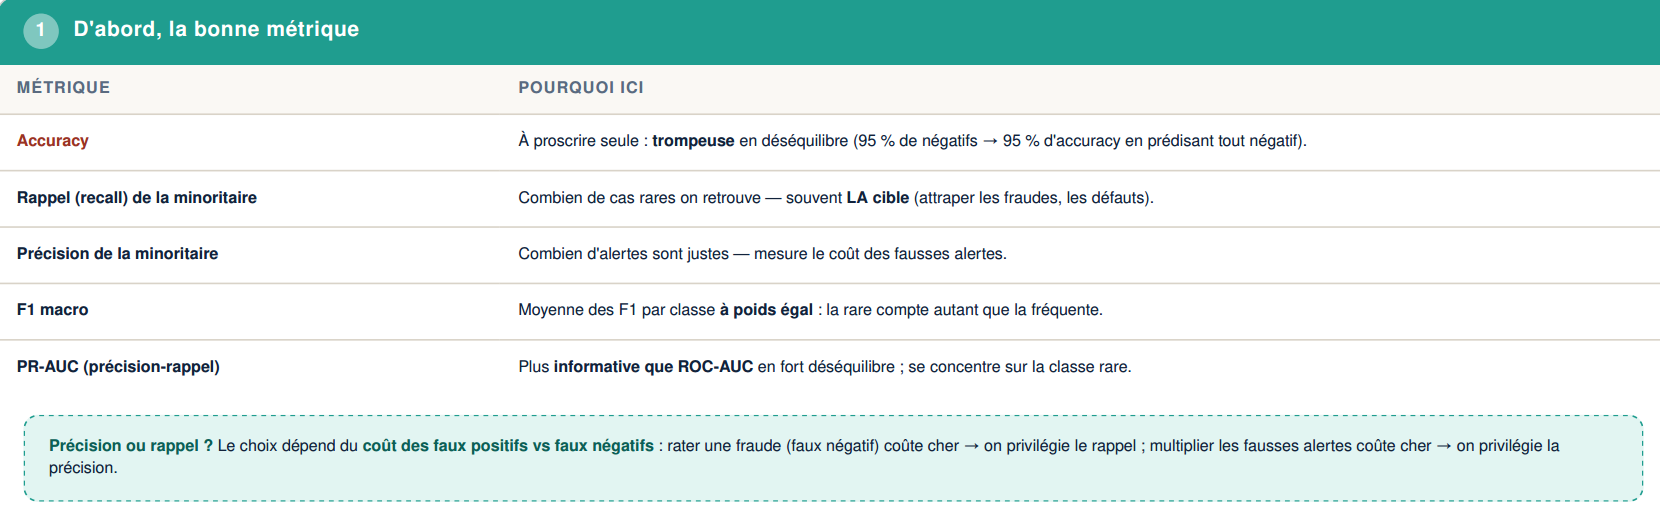
- Est-ce qu'on a des cas de OrdinalEncoder (categorie ordinale) ?
- Est-ce qu'il sera utile de mettre en place une DB des données (histo??) ? voir fiche_stockage_donnees.pdf ?
Etape 4 : 
- RAF : voir si on peut pas mieux sutrcturer l'étape 4 avec le pipeline car le pipeline de l'étape 4 n'est plus utilisé ensuite, donc c'est un peu dommage
Etape 6 :
- Arbitrage
...


## 📅 Journal de bord – Jour 4 (09/09/2026)

### 🔧 Étapes / Actions réalisées
- Reprise de tout ce qui avait été fait : 
    - reprise et reordonnancement des critères pour leur donner plus de sens, en 2 groupes : Suivi des erreurs et performances globale.
    - reprise de l'analyse des donnees sensisbles pour rester coherent
    - reprise des scenario suite au benchmark de la baseline pour ecarter les scenario non pertinents
    - reprise du benchmark pour grouper par scenario et verification de la coherence des metriques avec ceux des criteres
    - apres le benchmark des modeles, elimination du modele HGBC

### 📝 Observations / Difficultés
- Temps passé : 2h30

### ✅ Prochaines étapes
- Tracer les courbes d'apprentissage, si besoin se référer à fiche_biais_variance.pdf
- Appliquer un OrdinalEncoder sur le niveau de diplome
- Est-ce qu'il sera utile de mettre en place une DB des données (histo??) ? voir fiche_stockage_donnees.pdf ?
- Des éléments de l'étape 6 sont déja dans 5.6 et 5.7. Il faut juste restructurer les pragraphes pour que ce soit plus lisibles, et faire apparaitre clairement : le scenario a retenir (les meilleures features pour l'entrainement) et le meilleur modele avec son jeu d'hyperparam.
...


## 📅 Journal de bord – Jour 1 (JJ/MM/AAAA)

### 🔧 Étapes / Actions réalisées
- 

### 📝 Observations / Difficultés
- Temps passé : 
- ...

### ✅ Prochaines étapes
- ...